In [1]:
import pandas as pd

df = pd.read_csv("processed_motion_features.csv")
df.head()

,sequence,genre,num_frames,mean_motion,std_motion,max_motion,median_motion,total_displacement
0,gJS_sBM_cAll_d01_mJS1_ch02,gJS,640,0.130469,0.154842,0.689688,0.066611,83.369934
1,gHO_sBM_cAll_d21_mHO5_ch08,gHO,426,1.323334,0.401874,2.500633,1.321178,562.417100
2,gJS_sBM_cAll_d01_mJS0_ch02,gJS,720,0.124431,0.161430,0.796689,0.046617,89.465910
3,gWA_sBM_cAll_d25_mWA0_ch04,gWA,720,0.654191,0.421162,1.779965,0.497423,470.363370
4,gWA_sBM_cAll_d25_mWA0_ch10,gWA,720,0.943404,0.487555,2.674557,0.862939,678.307740


In [4]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(411, 8)
Index(['sequence', 'genre', 'num_frames', 'mean_motion', 'std_motion',
       'max_motion', 'median_motion', 'total_displacement'],
      dtype='object')
sequence              0
genre                 0
num_frames            0
mean_motion           0
std_motion            0
max_motion            0
median_motion         0
total_displacement    0
dtype: int64


In [5]:
X = df[["num_frames", "mean_motion", "std_motion", "max_motion", "median_motion", "total_displacement"]]
y = df["genre"]

print(X.head())
print(y.head())

   num_frames  mean_motion  std_motion  max_motion  median_motion  \
0         640     0.130469    0.154842    0.689688       0.066611   
1         426     1.323334    0.401874    2.500633       1.321178   
2         720     0.124431    0.161430    0.796689       0.046617   
3         720     0.654191    0.421162    1.779965       0.497423   
4         720     0.943404    0.487555    2.674557       0.862939   

   total_displacement  
0           83.369934  
1          562.417100  
2           89.465910  
3          470.363370  
4          678.307740  
0    gJS
1    gHO
2    gJS
3    gWA
4    gWA
Name: genre, dtype: object


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])
print(label_encoder.classes_)

[3 1 3 9 9 1 9 6 6 4]
['gBR' 'gHO' 'gJB' 'gJS' 'gKR' 'gLH' 'gLO' 'gMH' 'gPO' 'gWA']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(328, 6) (83, 6)
(328,) (83,)


## Machine Learning Models

To evaluate whether motion-based features can be used for dance genre classification, I trained three supervised learning models: Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest.

The input features were:
- `num_frames`
- `mean_motion`
- `std_motion`
- `max_motion`
- `median_motion`
- `total_displacement`

The target variable was `genre`, encoded as numeric labels.  
The dataset was split into training and test sets using an 80/20 ratio with stratification.

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.3493975903614458
              precision    recall  f1-score   support

         gBR       0.00      0.00      0.00         7
         gHO       0.38      0.75      0.50         8
         gJB       0.50      0.62      0.56         8
         gJS       0.36      0.44      0.40         9
         gKR       0.17      0.25      0.20         8
         gLH       0.00      0.00      0.00         9
         gLO       0.25      0.11      0.15         9
         gMH       0.57      0.44      0.50         9
         gPO       0.67      0.44      0.53         9
         gWA       0.43      0.43      0.43         7

    accuracy                           0.35        83
   macro avg       0.33      0.35      0.33        83
weighted avg       0.34      0.35      0.33        83



/Users/srlvnt/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/srlvnt/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/srlvnt/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/srlvnt/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/srlvnt/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_los

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.4819277108433735
              precision    recall  f1-score   support

         gBR       0.36      0.57      0.44         7
         gHO       0.64      0.88      0.74         8
         gJB       0.67      0.50      0.57         8
         gJS       0.36      0.44      0.40         9
         gKR       0.50      0.25      0.33         8
         gLH       0.44      0.44      0.44         9
         gLO       0.43      0.33      0.38         9
         gMH       0.38      0.56      0.45         9
         gPO       0.62      0.56      0.59         9
         gWA       0.67      0.29      0.40         7

    accuracy                           0.48        83
   macro avg       0.51      0.48      0.47        83
weighted avg       0.50      0.48      0.47        83



In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

KNN Accuracy: 0.39759036144578314
              precision    recall  f1-score   support

         gBR       0.18      0.29      0.22         7
         gHO       0.54      0.88      0.67         8
         gJB       0.80      0.50      0.62         8
         gJS       0.42      0.56      0.48         9
         gKR       0.12      0.12      0.12         8
         gLH       0.27      0.33      0.30         9
         gLO       0.43      0.33      0.38         9
         gMH       0.20      0.11      0.14         9
         gPO       0.71      0.56      0.62         9
         gWA       0.50      0.29      0.36         7

    accuracy                           0.40        83
   macro avg       0.42      0.40      0.39        83
weighted avg       0.42      0.40      0.39        83



In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.481928
1,KNN,0.397590
0,Logistic Regression,0.349398


## Model Comparison

Among the three models, Random Forest achieved the highest test accuracy (about 0.48), followed by KNN (about 0.40) and Logistic Regression (about 0.35).

This suggests that nonlinear models may be more suitable for this task than a simple linear baseline. Since dance motion patterns can be complex, Random Forest appears better at capturing differences between genres.

<Figure size 1000x800 with 0 Axes>

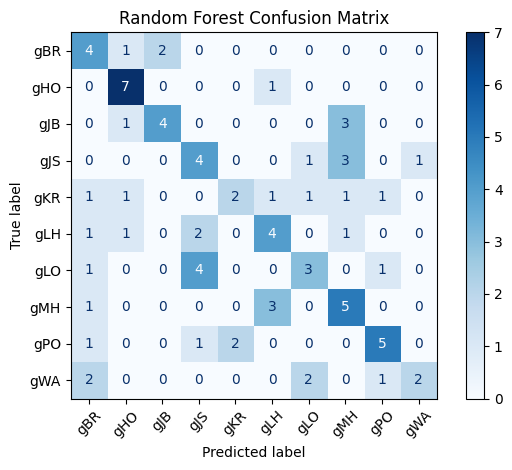

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The confusion matrix for Random Forest shows that some genres are predicted more accurately than others, while several genres are still confused with one another.

This indicates that the extracted motion-based features contain useful information, but they are not sufficient for perfect classification. Some dance genres may have overlapping movement characteristics, which makes the classification problem more difficult.

Overall, the results suggest that motion-based features are meaningful, but richer features or additional data may improve performance in future work.